<a href="https://colab.research.google.com/github/Muqqadas30/CodeAlpha_ML_Internship_Tasks/blob/main/task1/task1_credit_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix,
                               classification_report, roc_curve)

np.random.seed(42)

In [2]:
n_samples = 3000
data = pd.DataFrame({
    'age': np.random.randint(21, 65, n_samples),
    'income': np.random.randint(15000, 150000, n_samples),
    'debt': np.random.randint(0, 50000, n_samples),
    'existing_loans': np.random.randint(0, 5, n_samples),
    'credit_history_years': np.random.randint(0, 30, n_samples),
    'payment_delays': np.random.randint(0, 10, n_samples),
    'employment_years': np.random.randint(0, 40, n_samples),
    'num_credit_cards': np.random.randint(0, 10, n_samples),
    'savings': np.random.randint(0, 80000, n_samples),
})

data['debt_to_income'] = data['debt'] / (data['income'] + 1)
data['savings_to_income'] = data['savings'] / (data['income'] + 1)
data['loan_per_year_history'] = data['existing_loans'] / (data['credit_history_years'] + 1)

score = (
    (data['income'] / 1000) * 0.3
    - (data['debt_to_income'] * 100) * 0.5
    - (data['payment_delays']) * 2.5
    + (data['credit_history_years']) * 0.5
    + (data['employment_years']) * 0.3
    - (data['existing_loans']) * 1.5
    + (data['savings_to_income'] * 50) * 0.4
    - (data['num_credit_cards']) * 0.8
)
score += np.random.normal(0, 5, n_samples)
data['creditworthy'] = (score > np.percentile(score, 55)).astype(int)

X = data.drop('creditworthy', axis=1)
y = data['creditworthy']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [4]:
param_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=1000),
        "params": {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"], "solver": ["lbfgs"]}
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {"max_depth": [4, 6, 8, 10], "min_samples_split": [2, 5, 10]}
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [100, 200, 300], "max_depth": [6, 10, None], "min_samples_split": [2, 5]}
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=42, eval_metric="logloss"),
        "params": {"n_estimators": [100, 200], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.1, 0.2]}
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_estimators = {}

for name, mp in param_grids.items():
    grid = GridSearchCV(mp["model"], mp["params"], cv=cv, scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train_res, y_train_res)
    best_estimators[name] = grid.best_estimator_
    print(name, grid.best_params_, round(grid.best_score_, 4))

Logistic Regression {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'} 0.9836
Decision Tree {'max_depth': 6, 'min_samples_split': 10} 0.9112
Random Forest {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300} 0.973
XGBoost {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200} 0.9779


In [5]:
results = {}
for name, model in best_estimators.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

results_df = pd.DataFrame(results).T.round(4)
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.9350,0.9358,0.9185,0.9271,0.9857
Decision Tree,0.8183,0.7993,0.7963,0.7978,0.8878
Random Forest,0.8683,0.8659,0.8370,0.8512,0.9581
XGBoost,0.8967,0.8939,0.8741,0.8839,0.9737


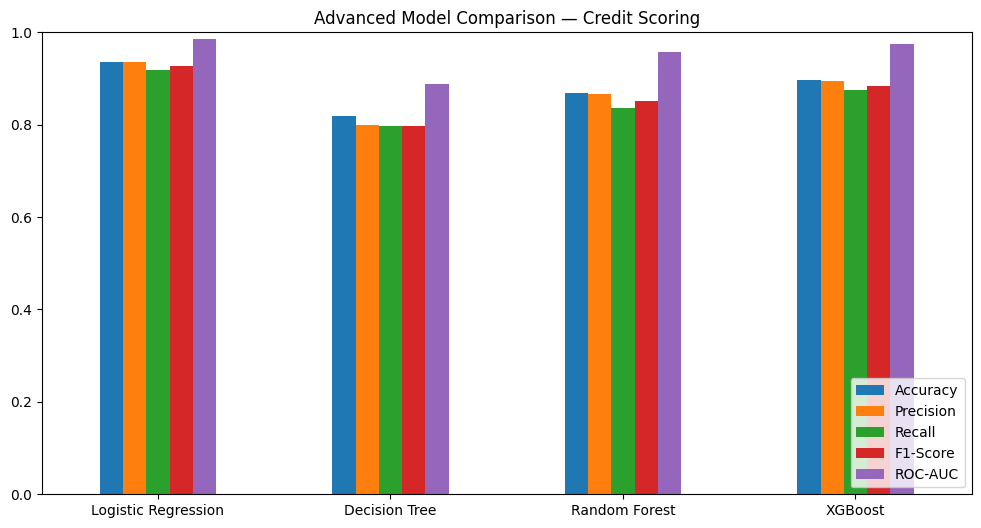

In [6]:
results_df.plot(kind='bar', figsize=(12,6))
plt.ylim(0,1)
plt.title('Advanced Model Comparison — Credit Scoring')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

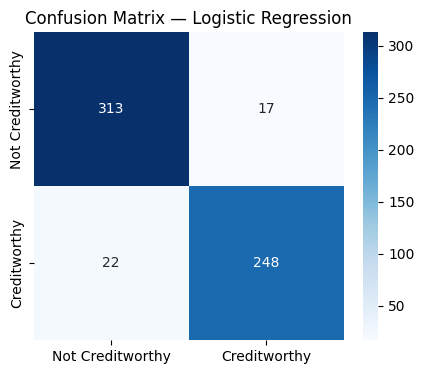

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       330
           1       0.94      0.92      0.93       270

    accuracy                           0.94       600
   macro avg       0.94      0.93      0.93       600
weighted avg       0.94      0.94      0.93       600



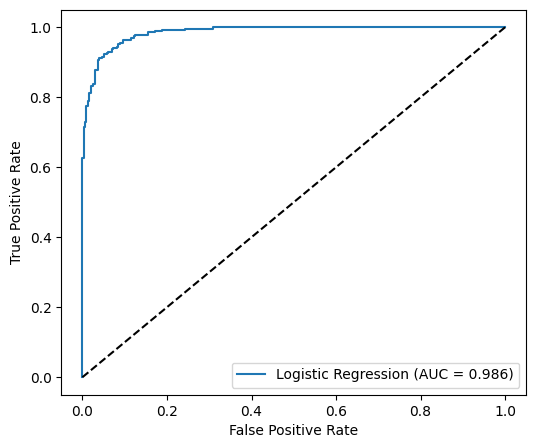

In [7]:
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = best_estimators[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Creditworthy', 'Creditworthy'],
            yticklabels=['Not Creditworthy', 'Creditworthy'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

print(classification_report(y_test, y_pred_best))

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc_score(y_test, y_proba_best):.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

[0.9832989  0.98987029 0.98289715 0.98311237 0.97869318] 0.9835743801652892 0.003583646268227421


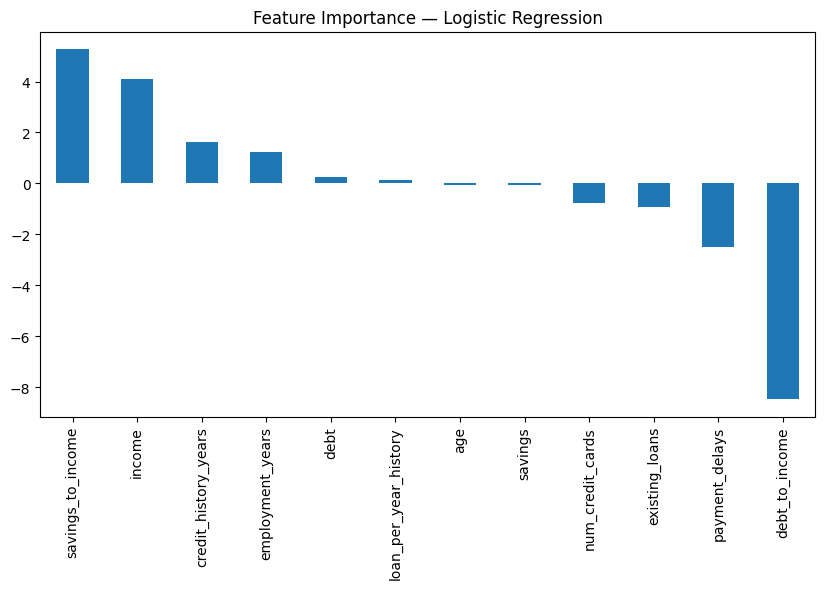

In [8]:
cv_scores = cross_val_score(best_model, X_train_res, y_train_res, cv=cv, scoring='roc_auc')
print(cv_scores, cv_scores.mean(), cv_scores.std())

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
else:
    importances = pd.Series(best_model.coef_[0], index=X.columns)

importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title(f'Feature Importance — {best_model_name}')
plt.show()